# fBERT: in-domain and cross-domain

Fine-tunes the fBERT checkpoint twice, each run starting from the base model:
- **In-domain:** train on `olid-train-small.csv`, test on `olid-test.csv`
- **Cross-domain:** train on `hasoc-train.csv`, test on `olid-test.csv`

`diptanu/fBERT` is a mirror of the original fBERT by Sarkar et al. (2021): a
`bert-base-uncased` model retrained on 1.4M offensive instances from the SOLID
dataset (the original `dieter2020/fBERT` hub repo is no longer available).

Hyperparameters are the simpletransformers defaults (no tuning). Trained models are
cached in `models/`, predictions in `results/`.

**Setup:**
```bash
source .venv/bin/activate
pip install torch transformers accelerate
```

In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

/home/s4ddo/Uni/Subjective/subjective-assignment-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
MODEL_NAME = "diptanu/fBERT"
SEED = 42
MAX_SEQ_LENGTH = 512
EVAL_BATCH_SIZE = 100

# simpletransformers ClassificationArgs defaults
TRAINING_ARGS = dict(
    num_train_epochs=1,
    learning_rate=4e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,
    warmup_steps=0.06,
    lr_scheduler_type="linear",
    weight_decay=0.0,
    adam_epsilon=1e-8,
    adam_beta1=0.9,
    adam_beta2=0.999,
    max_grad_norm=1.0,
    optim="adamw_torch",
    seed=SEED,
)

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [3]:
olid_train = pd.read_csv("data/olid-train-small.csv")
olid_test = pd.read_csv("data/olid-test.csv")
hasoc_train = pd.read_csv("data/hasoc-train.csv")

print("OLID train:", olid_train.shape)
print("OLID test:", olid_test.shape)
print("HASOC train:", hasoc_train.shape)

OLID train: (5852, 3)
OLID test: (860, 3)
HASOC train: (5852, 3)


In [4]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.encodings = tokenizer(list(df["text"]), truncation=True, max_length=MAX_SEQ_LENGTH)
        self.labels = list(df["labels"])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.encodings.items()}
        item["labels"] = self.labels[i]
        return item


def train_fbert(train_df, model_dir):
    if os.path.exists(os.path.join(model_dir, "config.json")):
        print(f"{model_dir} exists, skipping training")
        return

    set_seed(SEED)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = TrainingArguments(
        output_dir=model_dir,
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        dataloader_pin_memory=False,
        **TRAINING_ARGS,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=TextDataset(train_df, tokenizer),
        data_collator=DataCollatorWithPadding(tokenizer),
    )

    start = time.perf_counter()
    trainer.train()
    train_seconds = time.perf_counter() - start

    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)

    with open(os.path.join(model_dir, "train_info.json"), "w") as f:
        json.dump({"device": str(trainer.args.device), "train_seconds": round(train_seconds, 1)}, f)
    print(f"Trained on {trainer.args.device} in {train_seconds / 60:.1f} min")


@torch.no_grad()
def predict_fbert(model_dir, test_df):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE).eval()

    predictions = []
    for i in range(0, len(test_df), EVAL_BATCH_SIZE):
        batch = tokenizer(
            list(test_df["text"].iloc[i:i + EVAL_BATCH_SIZE]),
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)
        predictions.append(model(**batch).logits.argmax(dim=-1).cpu().numpy())

    return np.concatenate(predictions)

In [5]:
def run_fbert(train_df, test_df, experiment_name, model_dir, predictions_path):

    train_fbert(train_df, model_dir)

    if os.path.exists(predictions_path):
        print(f"{predictions_path} exists, loading saved predictions")
        results = pd.read_csv(predictions_path)
    else:
        results = test_df.copy()
        results["prediction"] = predict_fbert(model_dir, test_df)
        results["prediction_label"] = results["prediction"].map({0: "NOT", 1: "OFF"})
        results.to_csv(predictions_path, index=False)

    y_test = results["labels"]
    predictions = results["prediction"]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        labels=[0, 1],
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    accuracy = accuracy_score(y_test, predictions)

    cm = confusion_matrix(y_test, predictions, labels=[0, 1])

    with open(os.path.join(model_dir, "train_info.json")) as f:
        train_info = json.load(f)

    metrics = {
        "Experiment": experiment_name,
        "NOT Precision": precision[0],
        "NOT Recall": recall[0],
        "NOT F1": f1[0],
        "OFF Precision": precision[1],
        "OFF Recall": recall[1],
        "OFF F1": f1[1],
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Accuracy": accuracy,
        "Device": train_info["device"],
        "Train time (min)": train_info["train_seconds"] / 60
    }

    return results, metrics, cm

In [6]:
fb_olid_results, fb_olid_metrics, fb_cm_olid = run_fbert(
    olid_train,
    olid_test,
    "In-domain: OLID → OLID",
    "models/fbert-in-domain",
    "results/fbert_in-domain_predictions.csv"
)

fb_hasoc_results, fb_hasoc_metrics, fb_cm_hasoc = run_fbert(
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID",
    "models/fbert-cross-domain",
    "results/fbert_cross-domain_predictions.csv"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 23413.94it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: diptanu/fBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.555195
100,0.459218
150,0.480037
200,0.453434
250,0.445501
300,0.391671
350,0.425773
400,0.457504
450,0.468564
500,0.439803


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.28it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.27it/s]

Trained on cuda:0 in 0.7 min


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 24132.11it/s]

In [7]:
fb_comparison = pd.DataFrame([
    fb_olid_metrics,
    fb_hasoc_metrics
])

fb_comparison.round(4)

,Experiment,NOT Precision,NOT Recall,NOT F1,OFF Precision,OFF Recall,OFF F1,Macro Precision,Macro Recall,Macro F1,Accuracy,Device,Train time (min)
0,In-domain: OLID → OLID,0.8926,0.8984,0.8955,0.7331,0.7208,0.7269,0.8128,0.8096,0.8112,0.8488,cuda:0,0.6800
1,Cross-domain: HASOC → OLID,0.8646,0.9581,0.9090,0.8497,0.6125,0.7119,0.8572,0.7853,0.8104,0.8616,cuda:0,0.7383


In [8]:
fb_drop = (
    fb_olid_metrics["Macro F1"]
    - fb_hasoc_metrics["Macro F1"]
)

fb_relative_drop = (
    fb_drop / fb_olid_metrics["Macro F1"]
) * 100

print(f"In-domain Macro F1:   {fb_olid_metrics['Macro F1']:.4f}")
print(f"Cross-domain Macro F1: {fb_hasoc_metrics['Macro F1']:.4f}")
print(f"Absolute drop:         {fb_drop:.4f}")
print(f"Relative drop:         {fb_relative_drop:.2f}%")

In-domain Macro F1:   0.8112
Cross-domain Macro F1: 0.8104
Absolute drop:         0.0008
Relative drop:         0.10%


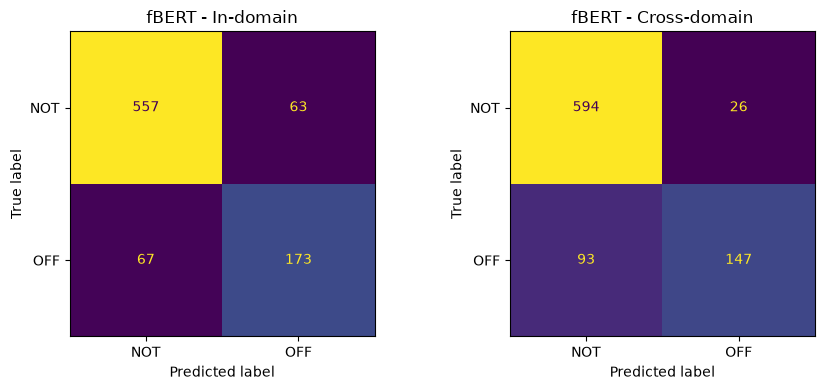

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, cm, title in [
    (axes[0], fb_cm_olid, "fBERT - In-domain"),
    (axes[1], fb_cm_hasoc, "fBERT - Cross-domain")
]:
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NOT", "OFF"]).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("figures/fbert_confusion_matrices.pdf", bbox_inches="tight")
plt.show()

In [10]:
def error_counts(results):

    false_positives = results[
        (results["labels"] == 0) &
        (results["prediction"] == 1)
    ]

    false_negatives = results[
        (results["labels"] == 1) &
        (results["prediction"] == 0)
    ]

    return len(false_positives), len(false_negatives)


olid_fp, olid_fn = error_counts(fb_olid_results)
hasoc_fp, hasoc_fn = error_counts(fb_hasoc_results)

print("IN-DOMAIN")
print("False positives:", olid_fp)
print("False negatives:", olid_fn)

print("\nCROSS-DOMAIN")
print("False positives:", hasoc_fp)
print("False negatives:", hasoc_fn)

IN-DOMAIN
False positives: 63
False negatives: 67

CROSS-DOMAIN
False positives: 26
False negatives: 93
